# Day 24: How do Decision Trees work?

---

## Objectives:

- Comprehend the fundamentals of **Decision Trees**.
- Learn about **Entropy**, **Gini Impurity**, and **Pruning**.
- Implement Decision Trees for classification tasks.
- Apply the model to a real-world dataset.
- Utilize robust visualizations to interpret results.

---

## 1. Introduction to Decision Trees

### 1.1 What is a Decision Tree?

A **Decision Tree** is a supervised learning algorithm used for both classification and regression tasks. It splits the data into subsets based on the value of input features, creating a tree-like model of decisions.

### 1.2 Key Components

- **Root Node**: Represents the entire dataset and initiates the splitting.
- **Internal Nodes**: Represent decisions based on features.
- **Leaf Nodes**: Represent final outcomes or predictions.

---

## 2. Splitting Criteria: Entropy and Gini Impurity

### 2.1 Entropy

**Entropy** measures the impurity or randomness in the data. It's calculated as:

\[ Entropy(S) = -\sum_{i=1}^{c} p_i \log_2(p_i) \]

Where \( p_i \) is the proportion of class \( i \) in the dataset \( S \).

- **Entropy = 0**: Pure subset (all instances belong to one class).
- **Entropy = 1**: Maximum impurity (instances are evenly distributed among classes).

### 2.2 Gini Impurity

**Gini Impurity** measures the probability of misclassifying a randomly chosen element. It's calculated as:

\[ Gini(S) = 1 - \sum_{i=1}^{c} p_i^2 \]

- **Gini = 0**: Pure subset.
- **Gini = 0.5**: Maximum impurity for a binary classification.

---

## 3. Pruning in Decision Trees

**Pruning** reduces the size of a decision tree by removing sections that provide little power in predicting target variables, thereby preventing overfitting.

- **Pre-Pruning (Early Stopping)**: Halts the tree growth before it becomes overly complex.
- **Post-Pruning**: Removes branches from a fully grown tree to improve generalization.

---

## 4. Dataset Overview

We'll use the **Iris Dataset**, a classic in machine learning, which includes:

- **Features**:
  - Sepal Length
  - Sepal Width
  - Petal Length
  - Petal Width
- **Target**:
  - Species (Setosa, Versicolor, Virginica)

---

## 5. Data Loading and Exploration

In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
#Load the data
iris = load_iris()
df = pd.DataFrame(data=iris.data,
                  columns=iris.feature_names)

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df['species'] = iris.target

## 6. EDA

In [6]:
#Summary Statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
#Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

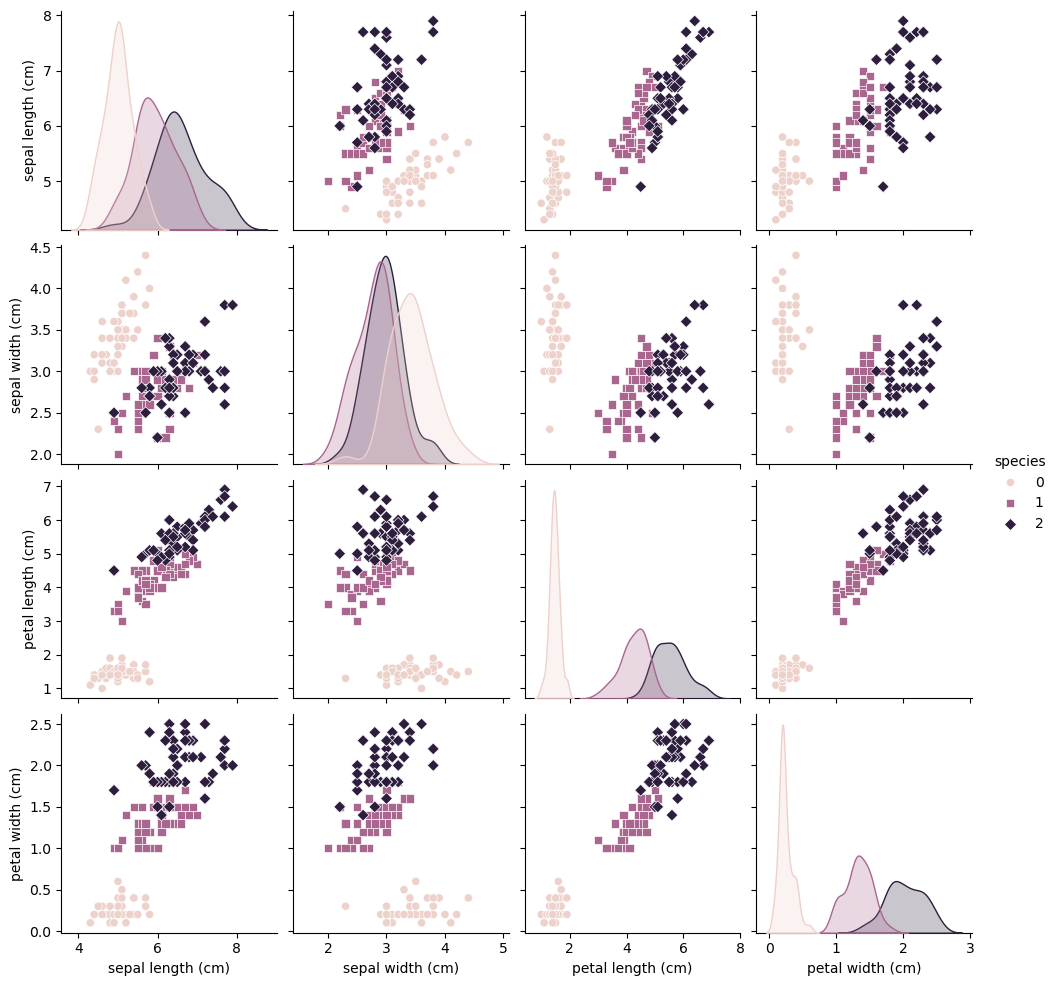

In [8]:
#Pairplot to visualize relationships
sns.pairplot(df, hue='species', markers=['o','s', 'D'])
plt.show()

## 7. Data Preprocessing

In [9]:
#Define feature variables (X) and target variable (y)
X = df.drop('species', axis=1)
y=df['species']

In [10]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Model Training

In [11]:
#Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## 9. Model Evaluation

In [12]:
#Predict on the test set
y_pred = dt_model.predict(X_test)

In [14]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



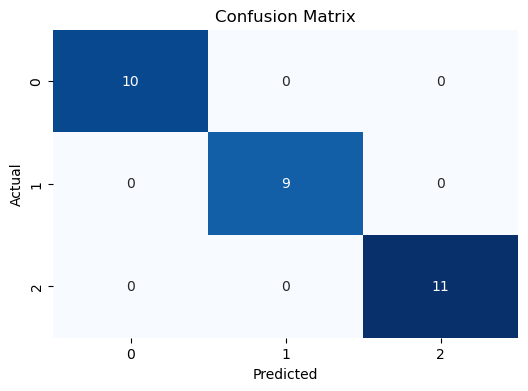

In [16]:
#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
#Accuracy Scoree
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


## 10. Decision Tree Visualization


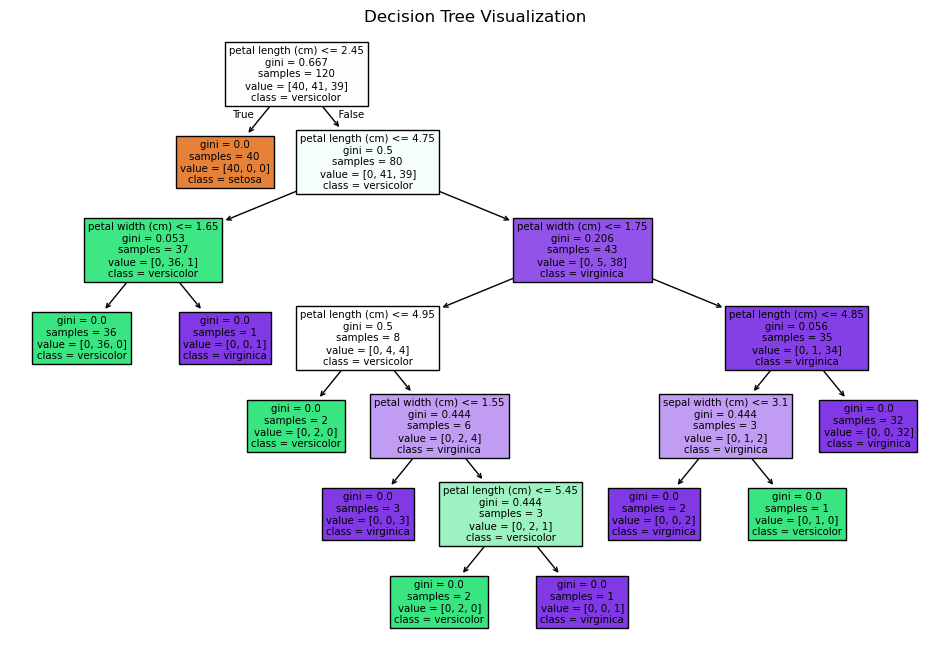

In [19]:
# Plot the decision Tree
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

## 11. Feature Importance

In [22]:
# Feature Importance
importances = dt_model.feature_importances_
feature_names = iris.feature_names

In [23]:
#Create a DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

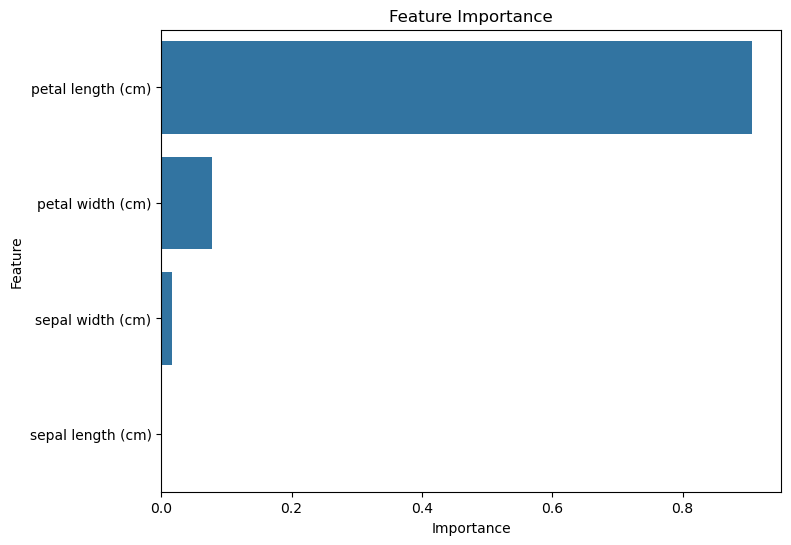

In [24]:
#Plot feature importance
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()

## 12. Pruning the Tree

In [25]:
#Initialize and train the pruned Decision Tree model
pruned_dt_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
pruned_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [26]:
#Predicted On the test set
y_pruned_pred = pruned_dt_model.predict(X_test)

In [27]:
#Classification report
print(classification_report(y_test, y_pruned_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



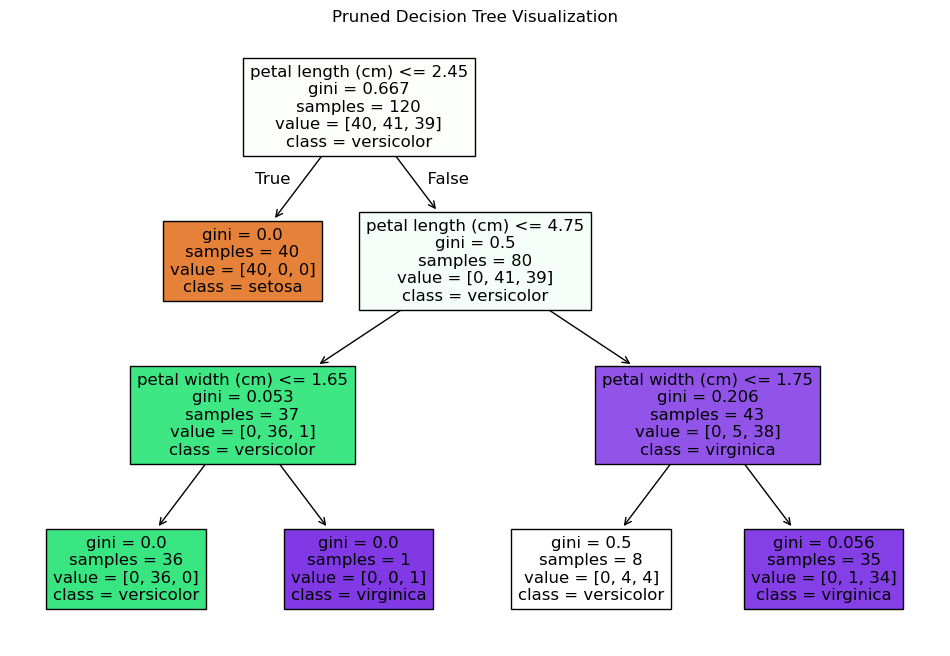

In [28]:
#Plot the pruned decision tree
plt.figure(figsize=(12,8))
plot_tree(pruned_dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title('Pruned Decision Tree Visualization')
plt.show()

## 13. Conclusion

In this notebook, we've:

- Explored the **Iris Dataset**.
- Understood key concepts: **Entropy**, **Gini Impurity**, and **Pruning**.
- Implemented a Decision Tree classifier.
- Evaluated the model using classification metrics and visualizations.
- Visualized the decision tree and identified important features.
- Applied pruning to improve model generalization.

Understanding Decision Trees and their components is crucial for building interpretable and effective machine learning models.